# WTI MM Fast/Slow Decomposition — Lead/Lag with Price

Decompose MM net positioning into two components:

- **MM-SLOW**: 13-week (3-month) moving average of MM net — captures
  the structural/strategic allocation that shifts slowly
- **MM-FAST**: residual (MM net - MM-SLOW) — captures short-term
  tactical trading relative to the 3-month baseline

Then run lead/lag analysis on the *changes* in each component vs price.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('../../../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load COT + prices

In [2]:
COT_PATH = '/Users/oualid/Documents/Projects/omroot_repos/cftc_data/cftc_downloads/disaggregated_combined.csv'

raw = pd.read_csv(COT_PATH, low_memory=False)
WTI_CODES = ['067651', '067411']
wti_raw = raw[raw['cftc_contract_market_code'].isin(WTI_CODES)].copy()
wti_raw['as_of_date'] = pd.to_datetime(wti_raw['report_date_as_yyyy_mm_dd'])

_SUM_COLS = ['open_interest_all',
             'm_money_positions_long_all', 'm_money_positions_short_all']
for c in _SUM_COLS:
    wti_raw[c] = pd.to_numeric(wti_raw[c], errors='coerce')

wti = wti_raw.groupby('as_of_date')[_SUM_COLS].sum().reset_index()
days_ahead = (4 - wti['as_of_date'].dt.dayofweek) % 7
wti['release_date'] = wti['as_of_date'] + pd.to_timedelta(days_ahead, unit='D')
wti['mm_net'] = wti['m_money_positions_long_all'] - wti['m_money_positions_short_all']
wti.sort_values('as_of_date', inplace=True)
wti.reset_index(drop=True, inplace=True)

# Prices
prices = pd.read_csv('../../../../cache/preprocessed_data/wti_prices_panel.csv',
                      usecols=['tradeDate', 'F1_RolledPrice'])
prices['tradeDate'] = pd.to_datetime(prices['tradeDate'])
prices.sort_values('tradeDate', inplace=True)

# Join prices on as_of_date (Tuesday), not release_date (Friday),
# to match the paper's P&L convention: position(Tue) * price_change(Tue-to-Tue)
wti = pd.merge_asof(
    wti.sort_values('as_of_date'),
    prices.rename(columns={'tradeDate': 'as_of_date'}),
    on='as_of_date', direction='backward', tolerance=pd.Timedelta(days=3),
)
wti.dropna(subset=['mm_net', 'F1_RolledPrice'], inplace=True)
wti.sort_values('as_of_date', inplace=True)
wti.reset_index(drop=True, inplace=True)

print(f'Rows: {len(wti)}')
print(f'Range: {wti["as_of_date"].min().date()} -> {wti["as_of_date"].max().date()}')

Rows: 813
Range: 2010-01-05 -> 2025-08-05


## 2. Decompose: MM-SLOW + MM-FAST

In [3]:
SLOW_WINDOW = 13  # 3-month moving average

wti['mm_slow'] = wti['mm_net'].rolling(SLOW_WINDOW, min_periods=SLOW_WINDOW).mean()
wti['mm_fast'] = wti['mm_net'] - wti['mm_slow']

# Weekly changes in each component
wti['mm_net_chg']  = wti['mm_net'].diff()
wti['mm_slow_chg'] = wti['mm_slow'].diff()
wti['mm_fast_chg'] = wti['mm_fast'].diff()
wti['price_ret']   = wti['F1_RolledPrice'].pct_change() * 100

df = wti.dropna(subset=['mm_fast_chg', 'price_ret']).reset_index(drop=True)
print(f'Clean rows: {len(df)}')
print(f'\nCorrelation of components (levels):')
print(f'  corr(mm_slow, mm_fast) = {df["mm_slow"].corr(df["mm_fast"]):.3f}')
print(f'\nVariance decomposition:')
var_net  = df['mm_net_chg'].var()
var_slow = df['mm_slow_chg'].var()
var_fast = df['mm_fast_chg'].var()
print(f'  Var(net_chg):  {var_net:12,.0f}')
print(f'  Var(slow_chg): {var_slow:12,.0f}  ({var_slow/var_net*100:.1f}%)')
print(f'  Var(fast_chg): {var_fast:12,.0f}  ({var_fast/var_net*100:.1f}%)')

Clean rows: 800

Correlation of components (levels):
  corr(mm_slow, mm_fast) = -0.107

Variance decomposition:
  Var(net_chg):   674,683,078
  Var(slow_chg):   55,684,910  (8.3%)
  Var(fast_chg):  649,949,142  (96.3%)


## 3. Visualise decomposition

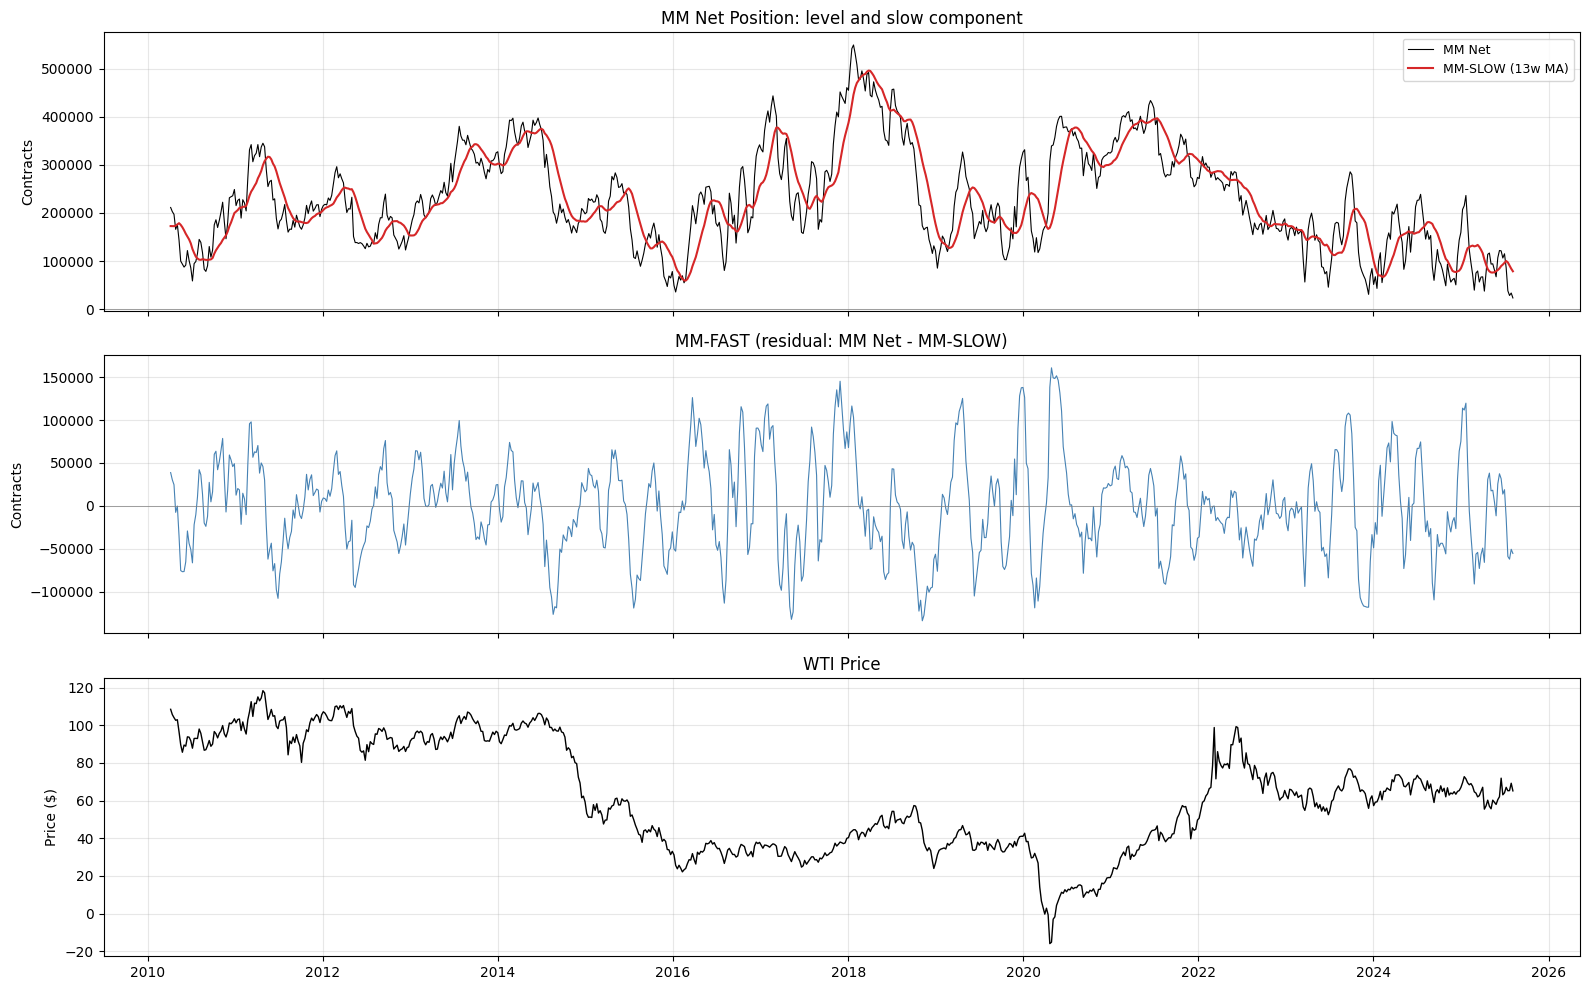

In [4]:
dt = pd.to_datetime(df['as_of_date'])

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

ax = axes[0]
ax.plot(dt, df['mm_net'], color='black', lw=0.8, label='MM Net')
ax.plot(dt, df['mm_slow'], color='tab:red', lw=1.5, label=f'MM-SLOW ({SLOW_WINDOW}w MA)')
ax.axhline(0, color='grey', lw=0.5)
ax.set_ylabel('Contracts')
ax.set_title('WTI MM Net Position: level and slow component')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(dt, df['mm_fast'], color='steelblue', lw=0.8)
ax.axhline(0, color='grey', lw=0.5)
ax.set_ylabel('Contracts')
ax.set_title('WTI MM-FAST (residual: MM Net - MM-SLOW)')

ax = axes[2]
ax.plot(dt, df['F1_RolledPrice'], color='black', lw=1)
ax.set_ylabel('Price ($)')
ax.set_title('WTI Price')

plt.tight_layout()
plt.show()

## 4. Contemporaneous correlation

In [5]:
print('Same-week Spearman: component change vs price return')
for label, col in [('MM Net change (total)',  'mm_net_chg'),
                    ('MM-SLOW change',         'mm_slow_chg'),
                    ('MM-FAST change',         'mm_fast_chg')]:
    rho, p = sp_stats.spearmanr(df[col], df['price_ret'])
    print(f'  {label:30s}  rho = {rho:+.3f}  (p = {p:.1e})')

Same-week Spearman: component change vs price return
  MM Net change (total)           rho = +0.624  (p = 2.0e-87)
  MM-SLOW change                  rho = +0.187  (p = 9.9e-08)
  MM-FAST change                  rho = +0.575  (p = 1.7e-71)


## 5. Cross-correlation function: MM-SLOW vs price

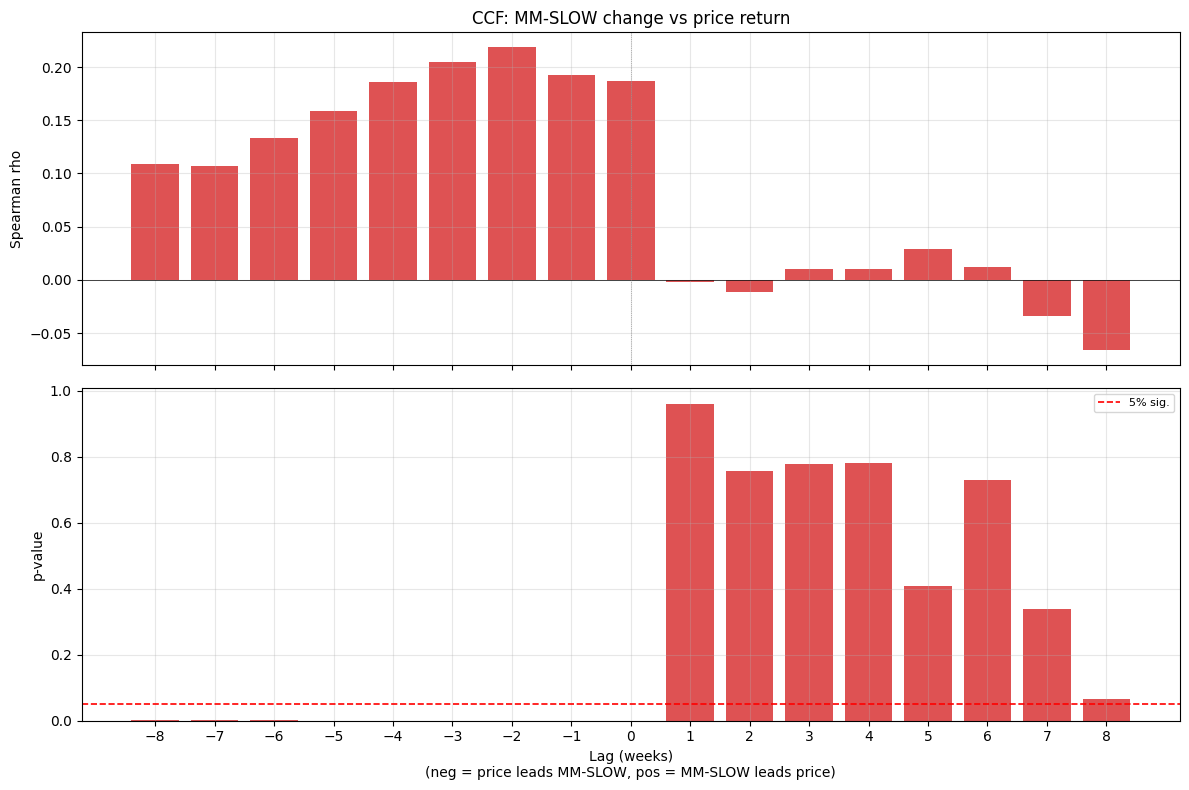

 Lag       rho       p-val
----------------------------
  -8   +0.109 *     2.1e-03
  -7   +0.107 *     2.6e-03
  -6   +0.134 *     1.6e-04
  -5   +0.158 *     7.3e-06
  -4   +0.186 *     1.3e-07
  -3   +0.205 *     5.0e-09
  -2   +0.218 *     4.5e-10
  -1   +0.193 *     4.1e-08
   0   +0.187 *     9.9e-08
   1   -0.002       9.6e-01
   2   -0.011       7.6e-01
   3   +0.010       7.8e-01
   4   +0.010       7.8e-01
   5   +0.029       4.1e-01
   6   +0.012       7.3e-01
   7   -0.034       3.4e-01
   8   -0.066       6.5e-02


In [6]:
MAX_LAG = 8

def compute_ccf(x, y, max_lag):
    lags = range(-max_lag, max_lag + 1)
    rhos, pvals = [], []
    for k in lags:
        if k >= 0:
            rho, p = sp_stats.spearmanr(x[:len(x)-k], y[k:])
        else:
            rho, p = sp_stats.spearmanr(x[-k:], y[:len(y)+k])
        rhos.append(rho)
        pvals.append(p)
    return list(lags), rhos, pvals

slow_vals = df['mm_slow_chg'].values
fast_vals = df['mm_fast_chg'].values
net_vals  = df['mm_net_chg'].values
price_vals = df['price_ret'].values

lags, rhos_slow, pvals_slow = compute_ccf(slow_vals, price_vals, MAX_LAG)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
ax.bar(lags, rhos_slow, color='tab:red', alpha=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='grey', lw=0.5, linestyle=':')
ax.set_ylabel('Spearman rho')
ax.set_title('CCF: WTI MM-SLOW change vs price return')

ax = axes[1]
ax.bar(lags, pvals_slow, color='tab:red', alpha=0.8)
ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% sig.')
ax.set_ylabel('p-value')
ax.set_xlabel('Lag (weeks)\n(neg = price leads MM-SLOW, pos = MM-SLOW leads price)')
ax.set_xticks(lags)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'{"Lag":>4s}  {"rho":>8s}  {"p-val":>10s}')
print('-' * 28)
for k, r, p in zip(lags, rhos_slow, pvals_slow):
    s = '*' if p < 0.05 else ' '
    print(f'{k:>4d}  {r:>+7.3f} {s}  {p:>10.1e}')

## 6. Cross-correlation function: MM-FAST vs price

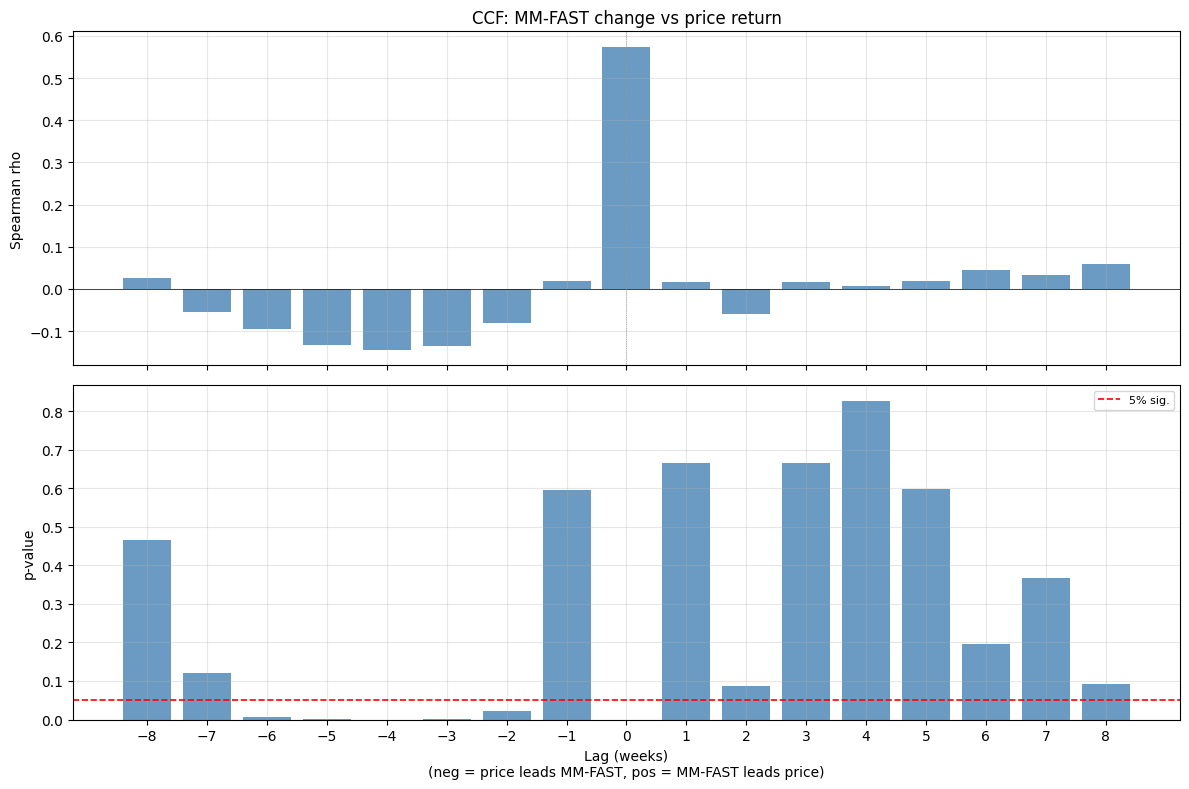

 Lag       rho       p-val
----------------------------
  -8   +0.026       4.7e-01
  -7   -0.055       1.2e-01
  -6   -0.095 *     7.4e-03
  -5   -0.134 *     1.5e-04
  -4   -0.146 *     3.7e-05
  -3   -0.135 *     1.4e-04
  -2   -0.080 *     2.3e-02
  -1   +0.019       6.0e-01
   0   +0.575 *     1.7e-71
   1   +0.015       6.6e-01
   2   -0.060       8.8e-02
   3   +0.015       6.7e-01
   4   +0.008       8.3e-01
   5   +0.019       6.0e-01
   6   +0.046       2.0e-01
   7   +0.032       3.7e-01
   8   +0.060       9.2e-02


In [7]:
_, rhos_fast, pvals_fast = compute_ccf(fast_vals, price_vals, MAX_LAG)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
ax.bar(lags, rhos_fast, color='steelblue', alpha=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='grey', lw=0.5, linestyle=':')
ax.set_ylabel('Spearman rho')
ax.set_title('CCF: WTI MM-FAST change vs price return')

ax = axes[1]
ax.bar(lags, pvals_fast, color='steelblue', alpha=0.8)
ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% sig.')
ax.set_ylabel('p-value')
ax.set_xlabel('Lag (weeks)\n(neg = price leads MM-FAST, pos = MM-FAST leads price)')
ax.set_xticks(lags)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'{"Lag":>4s}  {"rho":>8s}  {"p-val":>10s}')
print('-' * 28)
for k, r, p in zip(lags, rhos_fast, pvals_fast):
    s = '*' if p < 0.05 else ' '
    print(f'{k:>4d}  {r:>+7.3f} {s}  {p:>10.1e}')

## 7. Side-by-side comparison: total vs slow vs fast

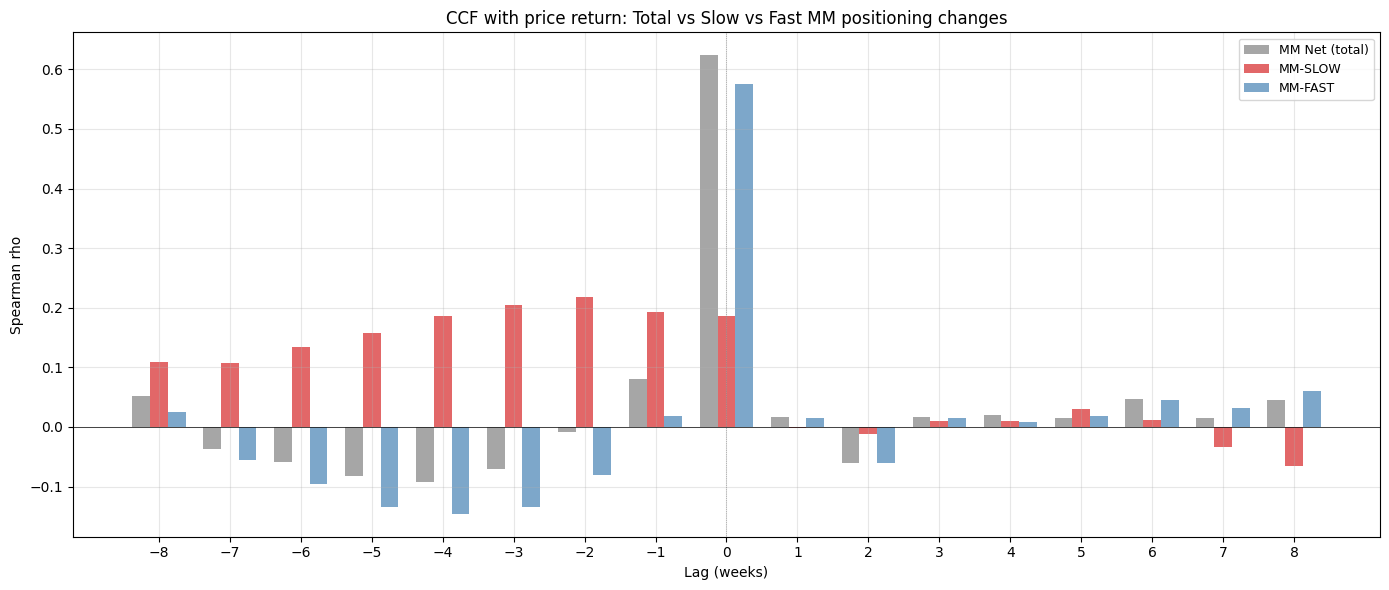

 Lag       Net      SLOW      FAST
-----------------------------------
  -8    +0.053    +0.109    +0.026
  -7    -0.036    +0.107    -0.055
  -6    -0.058    +0.134    -0.095
  -5    -0.083    +0.158    -0.134
  -4    -0.092    +0.186    -0.146
  -3    -0.070    +0.205    -0.135
  -2    -0.009    +0.218    -0.080
  -1    +0.080    +0.193    +0.019
   0    +0.624    +0.187    +0.575
   1    +0.017    -0.002    +0.015
   2    -0.060    -0.011    -0.060
   3    +0.016    +0.010    +0.015
   4    +0.020    +0.010    +0.008
   5    +0.016    +0.029    +0.019
   6    +0.047    +0.012    +0.046
   7    +0.015    -0.034    +0.032
   8    +0.045    -0.066    +0.060


In [8]:
_, rhos_net, _ = compute_ccf(net_vals, price_vals, MAX_LAG)

fig, ax = plt.subplots(figsize=(14, 6))
w = 0.25
x_pos = np.array(lags)
ax.bar(x_pos - w, rhos_net, w, color='grey', alpha=0.7, label='MM Net (total)')
ax.bar(x_pos, rhos_slow, w, color='tab:red', alpha=0.7, label='MM-SLOW')
ax.bar(x_pos + w, rhos_fast, w, color='steelblue', alpha=0.7, label='MM-FAST')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='grey', lw=0.5, linestyle=':')
ax.set_xlabel('Lag (weeks)')
ax.set_ylabel('Spearman rho')
ax.set_title('CCF with price return: Total vs Slow vs Fast WTI MM positioning changes')
ax.set_xticks(lags)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'{"Lag":>4s}  {"Net":>8s}  {"SLOW":>8s}  {"FAST":>8s}')
print('-' * 35)
for k, rn, rs, rf in zip(lags, rhos_net, rhos_slow, rhos_fast):
    print(f'{k:>4d}  {rn:>+8.3f}  {rs:>+8.3f}  {rf:>+8.3f}')

## 8. 5-year blocks

In [9]:
df['year'] = df['as_of_date'].dt.year

blocks_5y = [
    ('2010-2014', (2010, 2014)),
    ('2015-2019', (2015, 2019)),
    ('2020-2025', (2020, 2025)),
]

KEY = [-2, -1, 0, 1, 2]

for comp_label, comp_col in [('MM-SLOW', 'mm_slow_chg'), ('MM-FAST', 'mm_fast_chg')]:
    print(f'\n=== {comp_label} vs price return ===')
    print(f'{"Block":>12s}  {"n":>4s}', end='')
    for k in KEY:
        print(f'  lag {k:+d}', end='')
    print()
    print('-' * (22 + 9 * len(KEY)))

    for label, (y_start, y_end) in blocks_5y + [('Full sample', (2010, 2025))]:
        sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
        c_vals = sub[comp_col].values
        p_vals = sub['price_ret'].values
        print(f'{label:>12s}  {len(sub):>4d}', end='')
        for k in KEY:
            if k >= 0:
                rho, _ = sp_stats.spearmanr(
                    c_vals[:len(c_vals)-k] if k > 0 else c_vals,
                    p_vals[k:] if k > 0 else p_vals)
            else:
                rho, _ = sp_stats.spearmanr(c_vals[-k:], p_vals[:len(p_vals)+k])
            print(f'  {rho:+.3f}', end='')
        print()


=== MM-SLOW vs price return ===
       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2014   247  +0.242  +0.240  +0.236  +0.022  +0.032
   2015-2019   261  +0.282  +0.252  +0.211  +0.030  -0.006
   2020-2025   292  +0.176  +0.144  +0.176  -0.038  -0.020
 Full sample   800  +0.218  +0.193  +0.187  -0.002  -0.011

=== MM-FAST vs price return ===
       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2014   247  -0.110  -0.038  +0.712  -0.008  -0.121
   2015-2019   261  -0.033  +0.163  +0.550  +0.095  -0.072
   2020-2025   292  -0.094  -0.087  +0.538  -0.050  -0.015
 Full sample   800  -0.080  +0.019  +0.575  +0.015  -0.060


## 9. 3-year blocks

In [10]:
blocks_3y = [
    ('2010-2012', (2010, 2012)),
    ('2013-2015', (2013, 2015)),
    ('2016-2018', (2016, 2018)),
    ('2019-2021', (2019, 2021)),
    ('2022-2025', (2022, 2025)),
]

for comp_label, comp_col in [('MM-SLOW', 'mm_slow_chg'), ('MM-FAST', 'mm_fast_chg')]:
    print(f'\n=== {comp_label} vs price return ===')
    print(f'{"Block":>12s}  {"n":>4s}', end='')
    for k in KEY:
        print(f'  lag {k:+d}', end='')
    print()
    print('-' * (22 + 9 * len(KEY)))

    for label, (y_start, y_end) in blocks_3y + [('Full sample', (2010, 2025))]:
        sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
        c_vals = sub[comp_col].values
        p_vals = sub['price_ret'].values
        print(f'{label:>12s}  {len(sub):>4d}', end='')
        for k in KEY:
            if k >= 0:
                rho, _ = sp_stats.spearmanr(
                    c_vals[:len(c_vals)-k] if k > 0 else c_vals,
                    p_vals[k:] if k > 0 else p_vals)
            else:
                rho, _ = sp_stats.spearmanr(c_vals[-k:], p_vals[:len(p_vals)+k])
            print(f'  {rho:+.3f}', end='')
        print()


=== MM-SLOW vs price return ===
       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2012   143  +0.207  +0.198  +0.199  -0.022  -0.005
   2013-2015   156  +0.307  +0.316  +0.282  +0.092  +0.092
   2016-2018   157  +0.314  +0.313  +0.253  +0.078  +0.022
   2019-2021   156  +0.150  +0.120  +0.125  -0.011  +0.002
   2022-2025   188  +0.153  +0.136  +0.163  -0.115  -0.090
 Full sample   800  +0.218  +0.193  +0.187  -0.002  -0.011

=== MM-FAST vs price return ===
       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2012   143  -0.144  -0.050  +0.760  -0.047  -0.111
   2013-2015   156  -0.048  -0.061  +0.489  +0.060  +0.005
   2016-2018   157  -0.119  +0.196  +0.600  +0.121  -0.188
   2019-2021   156  -0.076  +0.014  +0.386  -0.083  -0.008
   2022-2025   188  -0.090  -0.062  +0.679  -0.007  -0.044
 Full sample   800  -0.080  +0.

## 10. 2-year blocks

In [11]:
blocks_2y = [
    ('2010-2011', (2010, 2011)),
    ('2012-2013', (2012, 2013)),
    ('2014-2015', (2014, 2015)),
    ('2016-2017', (2016, 2017)),
    ('2018-2019', (2018, 2019)),
    ('2020-2021', (2020, 2021)),
    ('2022-2023', (2022, 2023)),
    ('2024-2025', (2024, 2025)),
]

for comp_label, comp_col in [('MM-SLOW', 'mm_slow_chg'), ('MM-FAST', 'mm_fast_chg')]:
    print(f'\n=== {comp_label} vs price return ===')
    print(f'{"Block":>12s}  {"n":>4s}', end='')
    for k in KEY:
        print(f'  lag {k:+d}', end='')
    print()
    print('-' * (22 + 9 * len(KEY)))

    for label, (y_start, y_end) in blocks_2y + [('Full sample', (2010, 2025))]:
        sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
        c_vals = sub[comp_col].values
        p_vals = sub['price_ret'].values
        print(f'{label:>12s}  {len(sub):>4d}', end='')
        for k in KEY:
            if k >= 0:
                rho, _ = sp_stats.spearmanr(
                    c_vals[:len(c_vals)-k] if k > 0 else c_vals,
                    p_vals[k:] if k > 0 else p_vals)
            else:
                rho, _ = sp_stats.spearmanr(c_vals[-k:], p_vals[:len(p_vals)+k])
            print(f'  {rho:+.3f}', end='')
        print()


=== MM-SLOW vs price return ===
       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2011    91  +0.186  +0.163  +0.192  -0.018  -0.013
   2012-2013   104  +0.219  +0.242  +0.213  -0.069  -0.056
   2014-2015   104  +0.298  +0.282  +0.251  +0.102  +0.097
   2016-2017   104  +0.329  +0.282  +0.218  +0.007  -0.087
   2018-2019   105  +0.198  +0.224  +0.173  +0.023  +0.025
   2020-2021   104  +0.190  +0.159  +0.190  +0.045  +0.060
   2022-2023   104  +0.258  +0.256  +0.240  -0.183  -0.168
   2024-2025    84  +0.101  +0.028  +0.111  -0.102  -0.056
 Full sample   800  +0.218  +0.193  +0.187  -0.002  -0.011

=== MM-FAST vs price return ===
       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2011    91  -0.178  -0.030  +0.838  -0.006  -0.200
   2012-2013   104  -0.003  -0.034  +0.636  +0.006  +0.021
   2014-2015   104  -0.038  -0.

## 11. Rolling 104-week correlation at lag -1

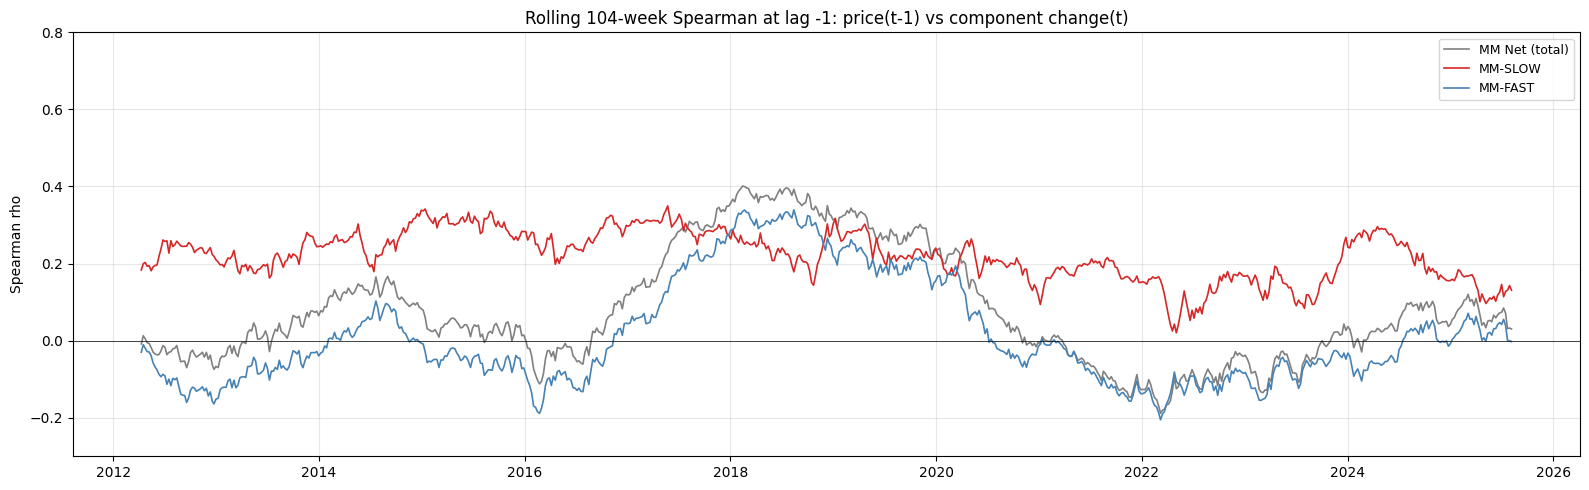

In [12]:
WINDOW = 104

fig, ax = plt.subplots(figsize=(16, 5))
for label, vals, color in [
    ('MM Net (total)', net_vals, 'grey'),
    ('MM-SLOW',        slow_vals, 'tab:red'),
    ('MM-FAST',        fast_vals, 'steelblue'),
]:
    rhos = [
        sp_stats.spearmanr(vals[i-WINDOW:i], price_vals[i-WINDOW-1:i-1]).statistic
        if i >= WINDOW + 1 else float('nan')
        for i in range(len(vals))
    ]
    ax.plot(dt, rhos, label=label, color=color, lw=1.2)

ax.axhline(0, color='black', lw=0.5)
ax.set_title(f'Rolling {WINDOW}-week Spearman at lag -1: WTI price(t-1) vs component change(t)')
ax.set_ylabel('Spearman rho')
ax.set_ylim(-0.3, 0.8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 12. Cumulative P&L: MM-SLOW vs MM-FAST

Following Bouchouev & Sun (2025), compute the realised P&L of each
component as if the positions were a trading strategy:

$$P\&L_t = \text{position}_{t-1} \times \Delta \text{price}_t$$

- **MM-SLOW** P&L: the slow (13w MA) position earns the weekly price change
- **MM-FAST** P&L: the residual position earns the weekly price change
- **MM total** P&L: the total MM net position earns the weekly price change

Positions are normalised to 100k contracts for comparability.

In [13]:
# Weekly price change
df['price_chg'] = df['F1_RolledPrice'].diff()

# P&L: position(t-1) * price_change(t), raw contracts
df['pnl_total'] = df['mm_net'].shift(1) * df['price_chg']
df['pnl_slow']  = df['mm_slow'].shift(1) * df['price_chg']
df['pnl_fast']  = df['mm_fast'].shift(1) * df['price_chg']

pnl = df.dropna(subset=['pnl_total', 'pnl_slow', 'pnl_fast']).copy()

pnl['cum_total'] = pnl['pnl_total'].cumsum()
pnl['cum_slow']  = pnl['pnl_slow'].cumsum()
pnl['cum_fast']  = pnl['pnl_fast'].cumsum()

ann = np.sqrt(52)
for label, col in [('MM Total', 'pnl_total'), ('MM-SLOW', 'pnl_slow'), ('MM-FAST', 'pnl_fast')]:
    sr = pnl[col].mean() / pnl[col].std() * ann
    total = pnl[col].sum()
    print(f'{label:12s}  cum P&L = ${total:>14,.0f}  Sharpe = {sr:+.2f}')


MM Total      cum P&L = $    -1,721,889  Sharpe = -0.02
MM-SLOW       cum P&L = $   -10,637,474  Sharpe = -0.12
MM-FAST       cum P&L = $     8,915,585  Sharpe = +0.45


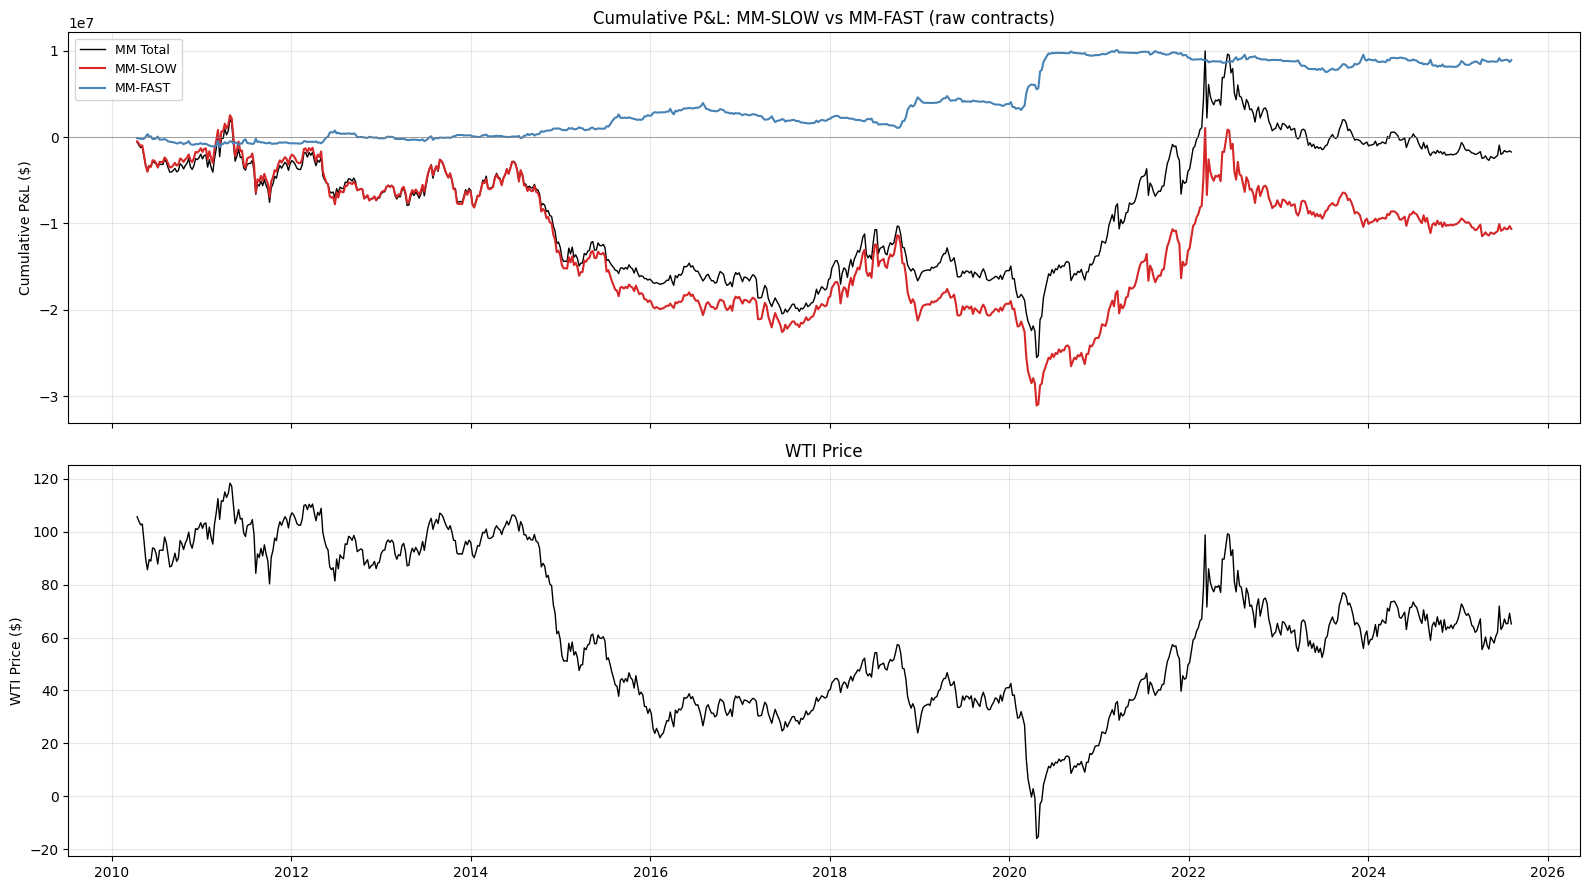

In [14]:
dt_pnl = pd.to_datetime(pnl['as_of_date'])

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Panel 1: Cumulative P&L
ax = axes[0]
ax.plot(dt_pnl, pnl['cum_total'], color='black', lw=1, label='MM Total')
ax.plot(dt_pnl, pnl['cum_slow'], color='tab:red', lw=1.5, label='MM-SLOW')
ax.plot(dt_pnl, pnl['cum_fast'], color='steelblue', lw=1.5, label='MM-FAST')
ax.axhline(0, color='grey', lw=0.5)
ax.set_ylabel('Cumulative P&L ($)')
ax.set_title('Cumulative P&L: WTI MM-SLOW vs MM-FAST (raw contracts)')
ax.legend(fontsize=9)

# Panel 2: WTI price for context
ax = axes[1]
ax.plot(dt_pnl, pnl['F1_RolledPrice'], color='black', lw=1)
ax.set_ylabel('WTI Price ($)')
ax.set_title('WTI Price')

plt.tight_layout()
plt.show()


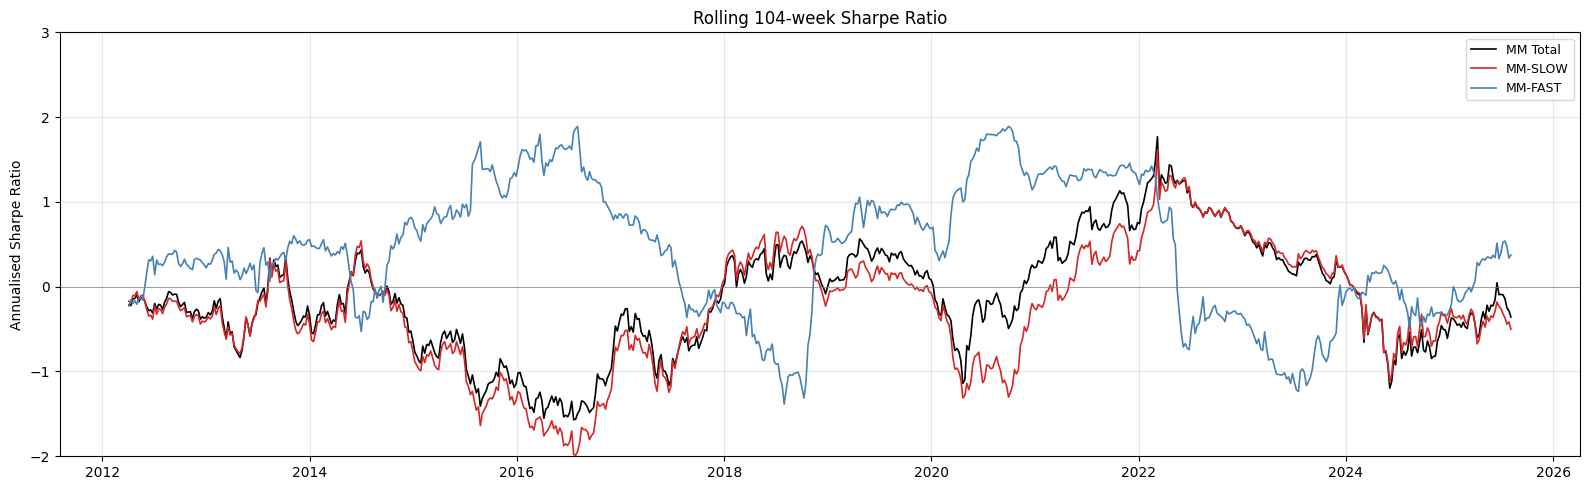

In [15]:
# Rolling 2-year Sharpe ratio
ROLL_W = 104

fig, ax = plt.subplots(figsize=(16, 5))
for label, col, color in [('MM Total', 'pnl_total', 'black'),
                           ('MM-SLOW', 'pnl_slow', 'tab:red'),
                           ('MM-FAST', 'pnl_fast', 'steelblue')]:
    roll_sr = pnl[col].rolling(ROLL_W).mean() / pnl[col].rolling(ROLL_W).std() * ann
    ax.plot(dt_pnl, roll_sr, color=color, lw=1.2, label=label)

ax.axhline(0, color='grey', lw=0.5)
ax.set_ylabel('Annualised Sharpe Ratio')
ax.set_title(f'Rolling {ROLL_W}-week Sharpe Ratio — WTI')
ax.set_ylim(-2, 3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
